In [11]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

from matplotlib import colormaps

In [12]:
api = wandb.Api()

In [13]:
EXPERIMENT_GROUP = "./artifacts/2024-02-s19/experiments/1-comparison-layers"

In [14]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    layers,
    training_size,
    use_val_split,
    contamination_level,
    verbose=False,
    
):
    
    assert use_val_split

    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-s19',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.use_val_split": use_val_split},
            {"config.layers": layers}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                                 
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
#         best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
#         best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
#             "val_agreement": ["mean", "std", "count"],
#             "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    layers="layer4",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

summary

we have 33 runs
df.shape: (11, 5)


lambda_layer   val_acc                 teacher_acc
                     mean       std count        mean
0         0.000  0.484302  0.012884     3    0.998664
1         0.001  0.502338  0.012727     3    0.998664
2         0.010  0.500334  0.022165     3    0.998664
3         0.100  0.496994  0.000000     3    0.998664
4         1.000  0.498998  0.005302     3    0.998664
5        10.000  0.510354  0.013343     3    0.998664
6       100.000  0.529726  0.009037     3    0.998664
7      1000.000  0.541082  0.017812     3    0.998664
8     10000.000  0.541750  0.018941     3    0.998664
9    100000.000  0.537742  0.005785     3    0.998664
10  1000000.000  0.529726  0.005785     3    0.998664

In [15]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    layers="layer1",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-identity:pca--uncentered",
    training_size=1.0,
    verbose=True,
    contamination_level=0.0,
    use_val_split=True
)

we have 33 runs
df.shape: (11, 5)


lambda_layer   val_acc                 teacher_acc
                     mean       std count        mean
0         0.000  0.488310  0.010087     3    0.998664
1         0.001  0.501002  0.006942     3    0.998664
2         0.010  0.487642  0.006122     3    0.998664
3         0.100  0.503006  0.036128     3    0.998664
4         1.000  0.542418  0.015306     3    0.998664
5        10.000  0.548430  0.016687     3    0.998664
6       100.000  0.538410  0.013641     3    0.998664
7      1000.000  0.538410  0.015306     3    0.998664
8     10000.000  0.550434  0.016074     3    0.998664
9    100000.000  0.535070  0.018367     3    0.998664
10  1000000.000  0.533066  0.029521     3    0.998664

# Comparison on `cifar100-resnet18-v1`

student: resnet18xscifarcompr1
experiment group: ./artifacts/2024-02-s19/experiments/1-comparison-layers
date: 2024-02-06 08:03:01.689062


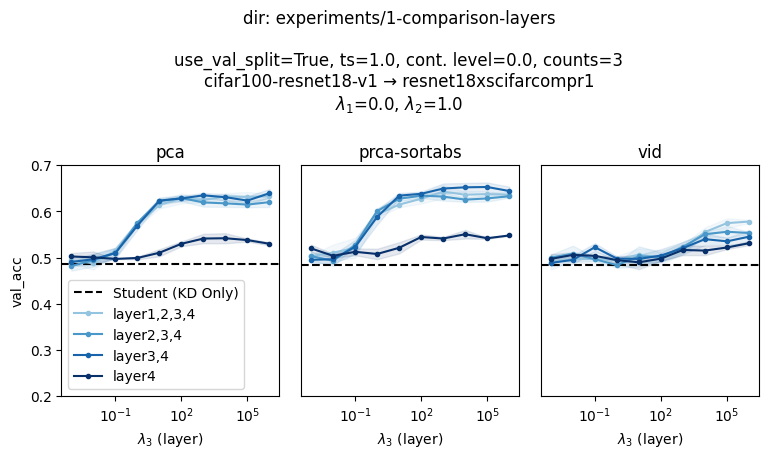

In [58]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def policy_alias(policy):
    
    return policy \
        .replace("basis-identity:", "") \
        .replace("--uncentered", "")

def layer_alias(layers):
    
    _mapping = {
        "layer1,layer2,layer3,layer4": "layer1,2,3,4",
        "layer2,layer3,layer4": "layer2,3,4",
        "layer3,layer4": "layer3,4",
        "layer4": "layer4",
    }
    
    return _mapping.get(layers, layers)

    
def viz_distillation(
    teacher, student, policies,
    show_legend=True,
    arr_layers=[
        "layer1,layer2,layer3,layer4",
        "layer2,layer3,layer4",
        "layer3,layer4",
        "layer4"
    ]
):
        

    contamination_level=0.0

    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    cmap = colormaps["Blues"]
    
    cmap_space = np.linspace(0.4, 1, 4)
    cmap_with_normalizer = lambda s: cmap(cmap_space[s])
    
    ncols = len(policies)
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"student: {student}")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(policy_alias(policy))
        
        for lix, layers in enumerate(arr_layers):

            df = read_data(
                teacher=teacher,
                student=student,
                layers=layers,
                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                contamination_level=contamination_level,
                use_val_split=use_val_split,
                verbose=False
            )


            with nullcontext(enter_result="sanity check"):            
                if count == None:

                    np.testing.assert_equal(
                        df[col]["count"].values,
                        df[col]["count"].values[0]
                    )

                    count = df[col]["count"].values[0]
                else:
                    np.testing.assert_equal(df[col]["count"].values, count)  
                    pass 

                if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                    or df[col]["count"].values[0] != count:
                        print(f"[warning] policy={policy}:", df[col]["count"].values)    



            if pix > 0:
                try:
                    np.testing.assert_allclose(
                        acc_student_kd_only,
                        df[col]["mean"].values[0],
                        atol=1e-2
                    )
                except Exception as err:
                    print(f"[policy={policy}] acc does not match!")
                    print(err)
            else:
                acc_student_kd_only = df[col]["mean"].values[0]

            if lix == 0:

                plt.axhline(
                    acc_student_kd_only,
                    ls="--",
                    color="k",
                    label="Student (KD Only)"
                )


            # here, we use [1:] to excluding lambda_layer=0
            assert df["lambda_layer"][0] == 0.0
            ticks = df["lambda_layer"][1:]
            mean = df[col]["mean"][1:]
            stderr = df[col]["std"][1:] / (count ** 0.5)


            plt.plot(
                ticks,
                mean,
                marker=".",
                label=layer_alias(layers),
                color=cmap_with_normalizer(lix)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.1,
                color=plt.gca().lines[-1].get_color()
            )


            plt.ylim([0.2, 0.7])
            plt.xscale("log")
            plt.xlabel("$\lambda_3$ (layer)")
            plt.ylabel(col)
            if pix == 0:
                plt.legend()

            if pix % ncols != 0:
                plt.ylabel("")
                plt.yticks([])

    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        "vid",
    ],
)

student: resnet18xscifarcompr1
experiment group: ./artifacts/2024-02-s19/experiments/1-comparison-layers
date: 2024-02-06 08:03:08.868049


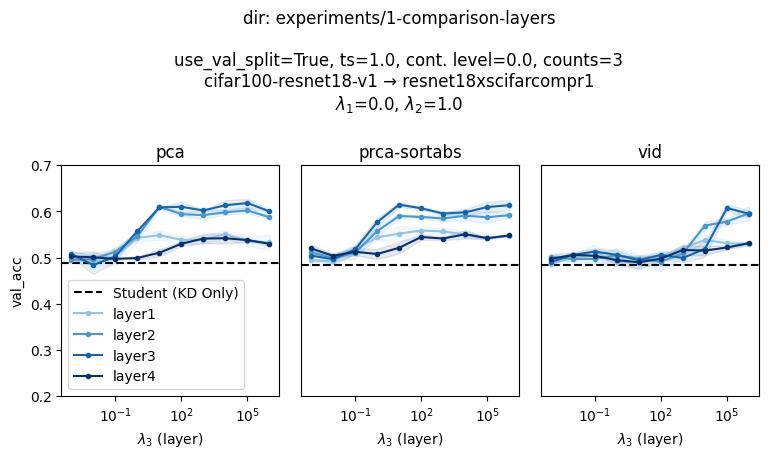

In [59]:

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
        "vid",
    ],
    arr_layers=[
        "layer1",
        "layer2",
        "layer3",
        "layer4",
    ]
)

student: resnet18xscifarcompr1
experiment group: ./artifacts/2024-02-s19/experiments/1-comparison-layers
date: 2024-02-06 08:02:21.386617


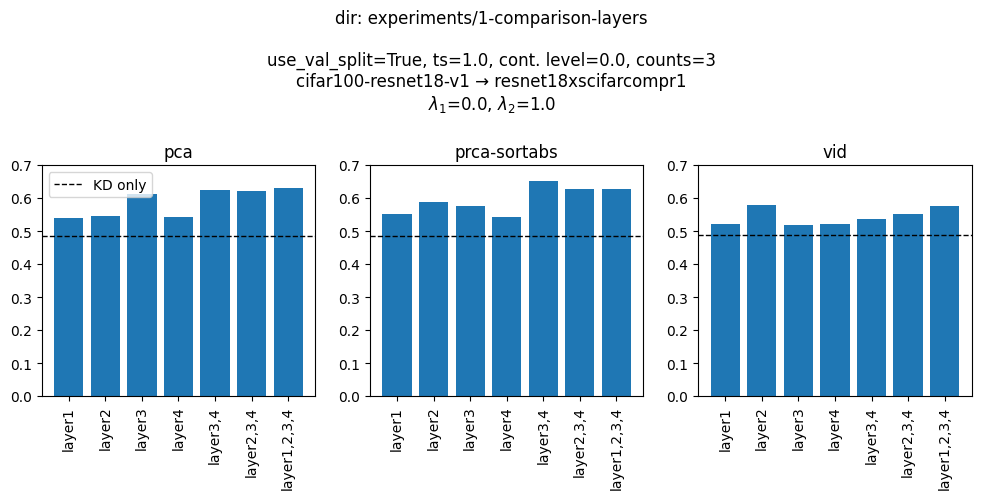

In [57]:
def viz_compare_across_layers(
    teacher, student, policies,
    show_legend=True,
    arr_layers=[
        "layer1",
        "layer2",
        "layer3",
        "layer4",
        
        "layer3,layer4",
        "layer2,layer3,layer4",
        "layer1,layer2,layer3,layer4",
    ]
):
        

    contamination_level=0.0

    training_size = 1.0
    use_val_split = True
    lambda_kd = 1.0
    lambda_task = 0.0
            
    col = "val_acc"
    
    cmap = colormaps["Blues"]
    
    cmap_space = np.linspace(0.4, 1, 4)
    cmap_with_normalizer = lambda s: cmap(cmap_space[s])
    
    ncols = len(policies)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"student: {student}")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for pix, policy in enumerate(policies):
        plt.subplot(nrows, ncols, pix+1)
        plt.title(policy_alias(policy))
        
        arr_statistics = np.zeros(
            (len(arr_layers), 2)
        )
        
        for lix, layers in enumerate(arr_layers):

            df = read_data(
                teacher=teacher,
                student=student,
                layers=layers,
                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                contamination_level=contamination_level,
                use_val_split=use_val_split,
                verbose=False
            )
            
            with nullcontext(enter_result="sanity check"):            
                if count == None:

                    np.testing.assert_equal(
                        df[col]["count"].values,
                        df[col]["count"].values[0]
                    )

                    count = df[col]["count"].values[0]
                else:
                    np.testing.assert_equal(df[col]["count"].values, count)  
                    pass 

                if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                    or df[col]["count"].values[0] != count:
                        print(f"[warning] policy={policy}:", df[col]["count"].values)    



            # here, we use [1:] to excluding lambda_layer=0
            assert df["lambda_layer"][0] == 0.0
            ticks = df["lambda_layer"][1:]
            
            acc_kd_only = df[col]["mean"].values[0]
            
            
            mean = df[col]["mean"][1:]
            stderr = df[col]["std"][1:] / (count ** 0.5)
            
            selected_ix = np.argmax(mean)
            arr_statistics[lix, :] = mean[selected_ix], stderr[selected_ix]
            
        plt.ylim([0., 0.7])
        plt.bar(
            np.arange(len(arr_layers)),
            arr_statistics[:, 0],
        )
        plt.xticks(
            np.arange(len(arr_layers)),
            list(map(lambda l: layer_alias(l), arr_layers)),
            rotation=90
        )
        
        plt.axhline(
            acc_kd_only, ls="--", lw=1, color="k",
            label="KD only"
        )
        if pix == 0:
            plt.legend()
    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"use_val_split={use_val_split}, ts={training_size}, cont. level={contamination_level}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
#     plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_compare_across_layers(
    teacher = "cifar100-resnet18-v1",
    student="resnet18xscifarcompr1",
    policies = [ 
        f"basis-identity:pca--uncentered",
        f"basis-identity:prca-sortabs--uncentered",
#         f"basis-identity:random--uncentered",
        "vid",
#         "attention-transfer",
#         "fitnet",
    ],
)

# Summary


*Conclusion:*
- each layer has its own distillation benefit
    - this follows from the observatio that attaching loss at each individual layer improves accuracy over only using KD only.
- having the layer-wise loss at multiple layers generally lead to better performance.